**Elaborado por** Juan Carlos Leal Cruz
# **Setup**

In [1]:
%pip install numpy matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

## Dataset

In [3]:
M = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]
L = [0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0]

n = len(M)

# **1. Dataset Visualization**

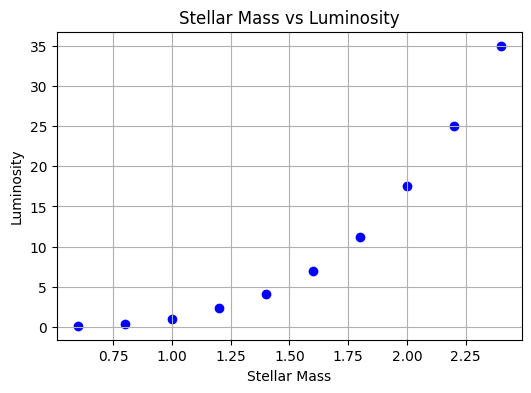

In [4]:
plt.figure(figsize=(6,4))
plt.scatter(M, L, color="blue")
plt.xlabel("Stellar Mass")
plt.ylabel("Luminosity")
plt.title("Stellar Mass vs Luminosity")
plt.grid(True)
plt.show()

## Discussion on Linearity and plausability

As we can see in the graphic generated based on the provided dataset, it is possible to stablish the following statements:
1. **Linearity**

   From the plot, we see:
   - Luminosity increases as mass increases, but not in a straight line
   - For low-mass stars, the increase in luminosity is small, while for higher-mass stars, luminosity grows rapidly.
   - The points form a curved trend, indicating that a simple linear model will not perfectly fit all data points.

   Interpretation for modeling: Linear regression will approximate the trend, but it cannot capture the accelerating growth at higher masses.

2. **Plausability**

   The trend makes sense:
   - Stars with more mass are generally brighter.
   - The sharp increase in luminosity for higher-mass stars is consistent with the idea that “larger systems produce more output faster.”
   - This is a realistic pattern for a system where output depends non-linearly on input.

   The data is realistic, and the shape reflects the system’s behavior, even though it is not linear.


# **2. Model and Loss**

In [5]:
def predict_luminosity(masses, w, b):
    predictions = []
    for i in range(len(masses)):
        predictions.append(w * masses[i] + b)
    return predictions

def compute_mse(masses, luminosities, w, b):
    total_error = 0.0
    for i in range(len(masses)):
        prediction = w * masses[i] + b
        error = prediction - luminosities[i]
        total_error += error ** 2
    return total_error / (2 * len(masses))

In [13]:
w_test = 0.0
b_test = 0.0

L_hat = predict_luminosity(M, w_test, b_test)
loss = compute_mse(M, L, w_test, b_test)

print("Predicted luminosities:", L_hat)
print("MSE loss:", loss)

Predicted luminosities: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
MSE loss: 117.69675


# **3. Cost Surface**

In [14]:
w_range = np.linspace(0, 30, 60)
b_range = np.linspace(-25, 10, 60)

W_grid = np.zeros((len(b_range), len(w_range)))
B_grid = np.zeros((len(b_range), len(w_range)))
J_grid = np.zeros((len(b_range), len(w_range)))

for i in range(len(b_range)):
    for j in range(len(w_range)):
        w_val = w_range[j]
        b_val = b_range[i]

        W_grid[i, j] = w_val
        B_grid[i, j] = b_val
        J_grid[i, j] = compute_mse(M, L, w_val, b_val)

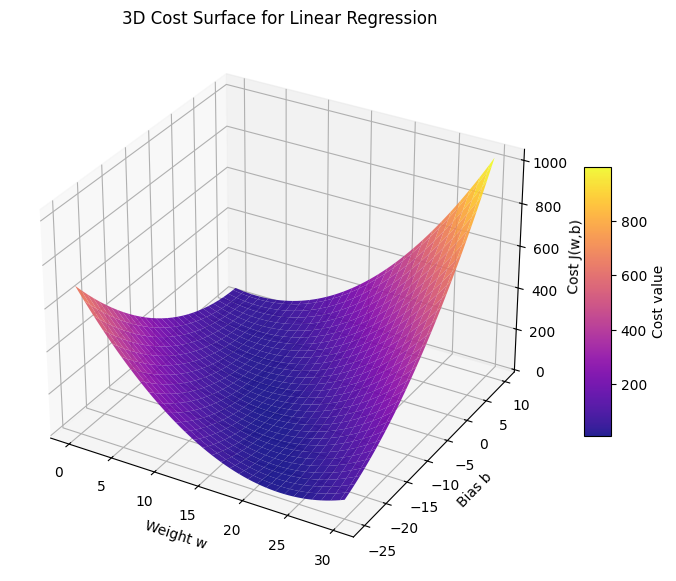

In [15]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    W_grid,
    B_grid,
    J_grid,
    cmap="plasma",
    edgecolor="none",
    alpha=0.9
)

ax.set_xlabel("Weight w")
ax.set_ylabel("Bias b")
ax.set_zlabel("Cost J(w,b)")
ax.set_title("3D Cost Surface for Linear Regression")

fig.colorbar(surface, shrink=0.5, aspect=10, label="Cost value")
plt.show()

### Interpretation

Each point on the surface corresponds to the value of the cost function computed on the entire stellar dataset for a specific pair (w,b). In ths particular case, the minimun represents the specific values that w and b can take in order to minimize the average squared difference between the predicted and observed stellar luminosities.

# **4. Gradients**

In [18]:
def gradients_explicit(masses, luminosities, w, b):
    grad_w = 0.0
    grad_b = 0.0
    n = len(masses)

    for k in range(n):
        prediction = w * masses[k] + b
        residual = prediction - luminosities[k]
        grad_w += residual * masses[k]
        grad_b += residual

    grad_w /= n
    grad_b /= n

    return grad_w, grad_b

In [19]:
w_test = 0.0
b_test = 0.0

dw, db = gradients_explicit(M, L, w_test, b_test)

print("Gradients evaluated at w = 0, b = 0")
print("dJ/dw =", dw)
print("dJ/db =", db)

Gradients evaluated at w = 0, b = 0
dJ/dw = -21.523000000000003
dJ/db = -10.36


# **5. Gradient Descent**

In [20]:
def run_gradient_descent(masses, luminosities, w_start, b_start, lr, steps):
    w = w_start
    b = b_start

    loss_history = []

    for step in range(steps):
        dw, db = gradients_explicit(masses, luminosities, w, b)

        w -= lr * dw
        b -= lr * db

        cost = compute_mse(masses, luminosities, w, b)
        loss_history.append(cost)

        if step % (steps // 10) == 0:
            print(f"Step {step:4d} | w = {w:8.4f} | b = {b:8.4f} | cost = {cost:10.4f}")

    return w, b, loss_history


In [21]:
learning_rate = 0.01
iterations = 1000

w0 = 0.0
b0 = 0.0

w_final, b_final, losses = run_gradient_descent(
    M, L, w0, b0, learning_rate, iterations
)

print("\nFinal learned parameters:")
print("w =", w_final)
print("b =", b_final)

Step    0 | w =   0.2152 | b =   0.1036 | cost =   112.0896
Step  100 | w =   6.8004 | b =   1.5699 | cost =    31.9704
Step  200 | w =   7.9674 | b =  -0.0073 | cost =    28.0913
Step  300 | w =   8.8900 | b =  -1.5257 | cost =    24.9336
Step  400 | w =   9.7253 | b =  -2.9093 | cost =    22.3208
Step  500 | w =  10.4849 | b =  -4.1680 | cost =    20.1590
Step  600 | w =  11.1759 | b =  -5.3129 | cost =    18.3703
Step  700 | w =  11.8044 | b =  -6.3543 | cost =    16.8903
Step  800 | w =  12.3762 | b =  -7.3015 | cost =    15.6658
Step  900 | w =  12.8962 | b =  -8.1632 | cost =    14.6525

Final learned parameters:
w = 13.364761102627167
b = -8.939532714878704


# **6. Gradient Descent (Vectorized)**

In [26]:
def gradients_vectorized(masses, luminosities, w, b):
    M_arr = np.array(masses)
    L_arr = np.array(luminosities)

    predictions = w * M_arr + b
    errors = predictions - L_arr

    dj_dw = np.mean(errors * M_arr)
    dj_db = np.mean(errors)

    return dj_dw, dj_db

def run_gradient_descent_vec(masses, luminosities, w_start, b_start, lr, steps):
    w = w_start
    b = b_start

    loss_history = []

    for step in range(steps):
        dj_dw, dj_db = gradients_vectorized(masses, luminosities, w, b)

        w -= lr * dj_dw
        b -= lr * dj_db

        cost = compute_mse(masses, luminosities, w, b)
        loss_history.append(cost)

        if step % (steps // 10) == 0:
            print(f"[Vec] Step {step:4d} | w={w:8.4f} | b={b:8.4f} | cost={cost:10.4f}")

    return w, b, loss_history

In [29]:
w_vec, b_vec, losses_vec = run_gradient_descent_vec(
    M, L, 0.0, 0.0, 0.01, 2000
)

print("\nFinal learned parameters (vectorized):")
print("w =", w_vec)
print("b =", b_vec)

[Vec] Step    0 | w=  0.2152 | b=  0.1036 | cost=  112.0896
[Vec] Step  200 | w=  7.9674 | b= -0.0073 | cost=   28.0913
[Vec] Step  400 | w=  9.7253 | b= -2.9093 | cost=   22.3208
[Vec] Step  600 | w= 11.1759 | b= -5.3129 | cost=   18.3703
[Vec] Step  800 | w= 12.3762 | b= -7.3015 | cost=   15.6658
[Vec] Step 1000 | w= 13.3693 | b= -8.9470 | cost=   13.8142
[Vec] Step 1200 | w= 14.1910 | b=-10.3085 | cost=   12.5466
[Vec] Step 1400 | w= 14.8709 | b=-11.4350 | cost=   11.6788
[Vec] Step 1600 | w= 15.4334 | b=-12.3670 | cost=   11.0847
[Vec] Step 1800 | w= 15.8989 | b=-13.1383 | cost=   10.6780

Final learned parameters (vectorized):
w = 16.2822484076734
b = -13.77345340049044


# **7. Convergence**

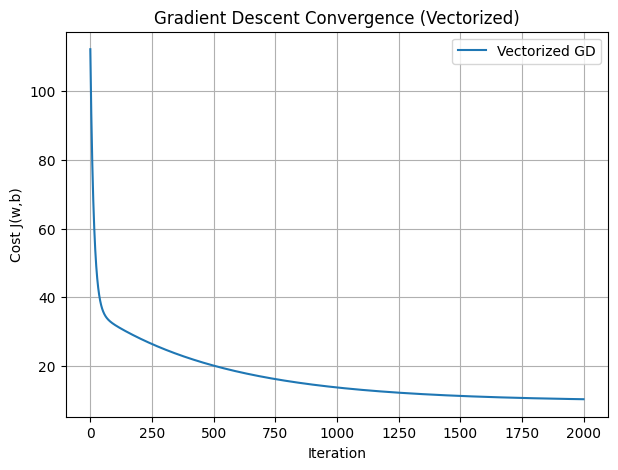

In [31]:
plt.figure(figsize=(7,5))
plt.plot(losses_vec, label='Vectorized GD')
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Gradient Descent Convergence (Vectorized)")
plt.grid(True)
plt.legend()
plt.show()

### Plot Loss VS Iterations

The convergence plot shows that the cost J(w,b) decreases rapidly in the first iterations, indicating that the initial updates significantly improve the model fit. As iterations progress, the curve flattens, showing that the algorithm is approaching the optimal parameters.
No oscillations are observed, confirming that the learning rate a=0.01 is appropriate for stable convergence.

# **8. Experiments**

In [32]:
learning_rates = [0.001, 0.01, 0.1]
num_iterations = 2000
w_init = 0.0
b_init = 0.0

experiment_results = []

for alpha in learning_rates:
    print(f"\nRunning gradient descent with learning rate alpha = {alpha}")
    w_learned, b_learned, loss_history = run_gradient_descent_vec(
        M, L, w_init, b_init, alpha, num_iterations
    )

    final_loss = loss_history[-1]
    experiment_results.append((alpha, w_learned, b_learned, final_loss))

    print(f"Final parameters for alpha={alpha}: w={w_learned:.4f}, b={b_learned:.4f}, loss={final_loss:.4f}")



Running gradient descent with learning rate alpha = 0.001
[Vec] Step    0 | w=  0.0215 | b=  0.0104 | cost=  117.1272
[Vec] Step  200 | w=  3.1775 | b=  1.3941 | cost=   55.5054
[Vec] Step  400 | w=  4.8589 | b=  1.8976 | cost=   39.5456
[Vec] Step  600 | w=  5.8048 | b=  1.9668 | cost=   34.9110
[Vec] Step  800 | w=  6.3826 | b=  1.8233 | cost=   33.1044
[Vec] Step 1000 | w=  6.7755 | b=  1.5774 | cost=   32.0220
[Vec] Step 1200 | w=  7.0742 | b=  1.2837 | cost=   31.1424
[Vec] Step 1400 | w=  7.3243 | b=  0.9696 | cost=   30.3358
[Vec] Step 1600 | w=  7.5483 | b=  0.6484 | cost=   29.5691
[Vec] Step 1800 | w=  7.7573 | b=  0.3268 | cost=   28.8333
Final parameters for alpha=0.001: w=7.9562, b=0.0096, loss=28.1290

Running gradient descent with learning rate alpha = 0.01
[Vec] Step    0 | w=  0.2152 | b=  0.1036 | cost=  112.0896
[Vec] Step  200 | w=  7.9674 | b= -0.0073 | cost=   28.0913
[Vec] Step  400 | w=  9.7253 | b= -2.9093 | cost=   22.3208
[Vec] Step  600 | w= 11.1759 | b= -5

In [33]:
print("\nSummary of experiments:")
print(f"{'Alpha':>8} | {'w':>8} | {'b':>8} | {'Final Loss':>12}")
print("-"*40)
for alpha, w, b, loss in experiment_results:
    print(f"{alpha:8.4f} | {w:8.4f} | {b:8.4f} | {loss:12.6f}")



Summary of experiments:
   Alpha |        w |        b |   Final Loss
----------------------------------------
  0.0010 |   7.9562 |   0.0096 |    28.129022
  0.0100 |  16.2822 | -13.7735 |    10.400701
  0.1000 |  18.1303 | -16.8355 |     9.795148


# **9. Final Fit Plot**

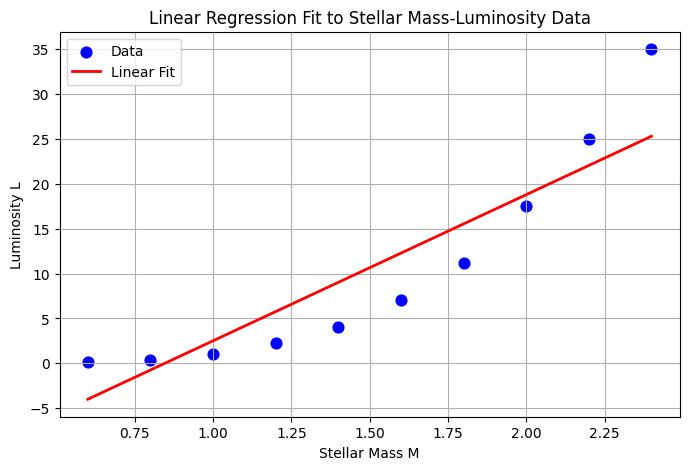

In [35]:
w_best = [res[1] for res in experiment_results if res[0] == 0.01][0]
b_best = [res[2] for res in experiment_results if res[0] == 0.01][0]

L_pred = predict_luminosity(M, w_best, b_best)

plt.figure(figsize=(8,5))
plt.scatter(M, L, color='blue', s=60, label='Data')
plt.plot(M, L_pred, color='red', linewidth=2, label='Linear Fit')
plt.xlabel("Stellar Mass M")
plt.ylabel("Luminosity L")
plt.title("Linear Regression Fit to Stellar Mass-Luminosity Data")
plt.grid(True)
plt.legend()
plt.show()


### Discussion about Systemaci Errors

The linear regression model captures the general trend of increasing luminosity with stellar mass, providing a reasonable approximation for low-mass stars (M<1.2) where the residuals are small and roughly random. However, for high-mass stars (M>1.6M), the model systematically underestimates the luminosity, reflecting the fact that stellar luminosity grows faster than linearly. This indicates that while a linear model can describe the overall trend, it cannot fully capture the curvature of the true mass-luminosity relationship, resulting in systematic errors at higher masses.

# **10. Conceptual Questions**

1. **Astrophysical meaning of w:** Indicates the rate at which stellar luminosity changes with stellar mass. Physically, it tells us how much brighter a star becomes for each additional solar mass.
2. **Why is a linear model limited here?** A linear model assumes a constant increase in luminosity per unit mass. In reality, luminosity grows faster than linearly with mass, so a straight line cannot capture the steep increase for high-mass stars.